# 🎯 Facial Recognition Attendance System - Model Accuracy Analysis

This notebook provides comprehensive accuracy analysis for the Facial Recognition Attendance System.

**System Components Analyzed:**
- Face Detection (MTCNN/RetinaFace)
- Face Recognition (FaceNet/ArcFace)
- Anti-Spoofing/Liveness Detection
- Overall System Performance

## 1. Setup and Imports

Import all required libraries for model evaluation and visualization.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys
import cv2
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Seaborn version: {sns.__version__}")

✅ All libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.2.6
OpenCV version: 4.12.0
Seaborn version: 0.13.2


## 2. Load Face Database and Embeddings

Load the trained face embeddings and student information for evaluation.

In [2]:
# Configuration paths
DATA_DIR = 'data'
EMBEDDINGS_DIR = os.path.join(DATA_DIR, 'embeddings')
FACES_DIR = os.path.join(DATA_DIR, 'faces')
DATABASE_PATH = os.path.join(DATA_DIR, 'attendance.db')

# File paths
EMBEDDINGS_PATH = os.path.join(EMBEDDINGS_DIR, 'face_embeddings.pkl')
MULTI_EMBEDDINGS_PATH = os.path.join(EMBEDDINGS_DIR, 'face_multi_embeddings.pkl')
STUDENT_INFO_PATH = os.path.join(EMBEDDINGS_DIR, 'student_info.pkl')

print("🔍 Checking file paths...")
print(f"Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Faces directory: {FACES_DIR}")
print(f"Database path: {DATABASE_PATH}")

# Check if files exist
files_exist = {
    'Embeddings': os.path.exists(EMBEDDINGS_PATH),
    'Multi-Embeddings': os.path.exists(MULTI_EMBEDDINGS_PATH),
    'Student Info': os.path.exists(STUDENT_INFO_PATH),
    'Database': os.path.exists(DATABASE_PATH),
    'Faces Dir': os.path.exists(FACES_DIR)
}

for file_name, exists in files_exist.items():
    status = "✅ Found" if exists else "❌ Missing"
    print(f"{file_name}: {status}")

if not files_exist['Embeddings']:
    print("\n⚠️ Embeddings file not found. Please train the model first:")
    print("  1. Register students via the API")
    print("  2. Run training to generate embeddings")

🔍 Checking file paths...
Embeddings directory: data/embeddings
Faces directory: data/faces
Database path: data/attendance.db
Embeddings: ✅ Found
Multi-Embeddings: ✅ Found
Student Info: ✅ Found
Database: ✅ Found
Faces Dir: ✅ Found


In [3]:
# Load embeddings and student information
print("📥 Loading face embeddings and student data...")

embeddings = {}
multi_embeddings = {}
student_info = {}

try:
    # Load primary embeddings
    if os.path.exists(EMBEDDINGS_PATH):
        with open(EMBEDDINGS_PATH, 'rb') as f:
            embeddings = pickle.load(f)
        print(f"✅ Loaded {len(embeddings)} face embeddings")
    
    # Load multi-embeddings
    if os.path.exists(MULTI_EMBEDDINGS_PATH):
        with open(MULTI_EMBEDDINGS_PATH, 'rb') as f:
            multi_embeddings = pickle.load(f)
        print(f"✅ Loaded multi-embeddings for {len(multi_embeddings)} students")
    
    # Load student info
    if os.path.exists(STUDENT_INFO_PATH):
        with open(STUDENT_INFO_PATH, 'rb') as f:
            student_info = pickle.load(f)
        print(f"✅ Loaded info for {len(student_info)} students")
    
    # Display embedding statistics
    if embeddings:
        sample_emb = list(embeddings.values())[0]
        print(f"\n📊 Embedding Statistics:")
        print(f"  Embedding dimension: {sample_emb.shape[0]}")
        print(f"  Data type: {sample_emb.dtype}")
        print(f"  Total registered students: {len(embeddings)}")
        
        # Count multi-embeddings
        if multi_embeddings:
            total_multi = sum(len(v) for v in multi_embeddings.values())
            avg_per_student = total_multi / len(multi_embeddings) if multi_embeddings else 0
            print(f"  Total multi-embeddings: {total_multi}")
            print(f"  Average embeddings per student: {avg_per_student:.1f}")
    else:
        print("\n⚠️ No embeddings found. Please train the model first.")
        
except Exception as e:
    print(f"❌ Error loading embeddings: {e}")

📥 Loading face embeddings and student data...
✅ Loaded 3 face embeddings
✅ Loaded multi-embeddings for 3 students
✅ Loaded info for 3 students

📊 Embedding Statistics:
  Embedding dimension: 512
  Data type: float32
  Total registered students: 3
  Total multi-embeddings: 30
  Average embeddings per student: 10.0


In [4]:
# Display student information summary
print("👥 Registered Students Summary:")
print("="*60)

if student_info:
    students_df = pd.DataFrame([
        {
            'Student ID': sid,
            'Name': info.get('name', 'N/A'),
            'Registered': info.get('registered_at', 'N/A')[:10] if info.get('registered_at') else 'N/A',
            'Num Embeddings': info.get('num_embeddings', 1)
        }
        for sid, info in student_info.items()
    ])
    
    print(students_df.to_string(index=False))
    print(f"\n📈 Total Students: {len(students_df)}")
    print(f"📈 Total Embeddings: {students_df['Num Embeddings'].sum()}")
else:
    print("No student information available.")

👥 Registered Students Summary:
       Student ID                Name Registered  Num Embeddings
DASH_stu-00000078 tharusha Senanayake 2026-01-11              10
DASH_stu-00000080     Sanduni Rodrigo 2026-01-11              10
DASH_stu-00000079  Kavinda Abeysekara 2026-01-11              10

📈 Total Students: 3
📈 Total Embeddings: 30


## 3. Face Recognition Model Analysis

Analyze embedding quality and similarity distributions.

In [5]:
# Analyze embedding quality using inter-class and intra-class similarity
print("🔬 Analyzing Embedding Quality...")

def cosine_similarity(emb1, emb2):
    """Calculate cosine similarity between two embeddings."""
    return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

# Calculate intra-class similarity (same person, different embeddings)
intra_class_similarities = []
if multi_embeddings:
    for student_id, embs in multi_embeddings.items():
        if len(embs) >= 2:
            for i in range(len(embs)):
                for j in range(i + 1, len(embs)):
                    sim = cosine_similarity(embs[i], embs[j])
                    intra_class_similarities.append(sim)

# Calculate inter-class similarity (different persons)
inter_class_similarities = []
if len(embeddings) >= 2:
    student_ids = list(embeddings.keys())
    for i in range(len(student_ids)):
        for j in range(i + 1, len(student_ids)):
            sim = cosine_similarity(
                embeddings[student_ids[i]],
                embeddings[student_ids[j]]
            )
            inter_class_similarities.append(sim)

print(f"\n📊 Similarity Analysis:")
print("-"*50)

if intra_class_similarities:
    print(f"Intra-class (Same Person):")
    print(f"  Mean Similarity: {np.mean(intra_class_similarities):.4f}")
    print(f"  Std Deviation: {np.std(intra_class_similarities):.4f}")
    print(f"  Min: {np.min(intra_class_similarities):.4f}")
    print(f"  Max: {np.max(intra_class_similarities):.4f}")

if inter_class_similarities:
    print(f"\nInter-class (Different Persons):")
    print(f"  Mean Similarity: {np.mean(inter_class_similarities):.4f}")
    print(f"  Std Deviation: {np.std(inter_class_similarities):.4f}")
    print(f"  Min: {np.min(inter_class_similarities):.4f}")
    print(f"  Max: {np.max(inter_class_similarities):.4f}")

# Calculate separation margin
if intra_class_similarities and inter_class_similarities:
    margin = np.mean(intra_class_similarities) - np.mean(inter_class_similarities)
    print(f"\n🎯 Class Separation Margin: {margin:.4f}")
    if margin > 0.3:
        print("✅ Excellent class separation!")
    elif margin > 0.2:
        print("✅ Good class separation")
    elif margin > 0.1:
        print("⚠️ Moderate class separation")
    else:
        print("❌ Poor class separation - consider retraining")

🔬 Analyzing Embedding Quality...

📊 Similarity Analysis:
--------------------------------------------------
Intra-class (Same Person):
  Mean Similarity: 0.8305
  Std Deviation: 0.0889
  Min: 0.5799
  Max: 0.9381

Inter-class (Different Persons):
  Mean Similarity: 0.3995
  Std Deviation: 0.3816
  Min: 0.1072
  Max: 0.9385

🎯 Class Separation Margin: 0.4310
✅ Excellent class separation!


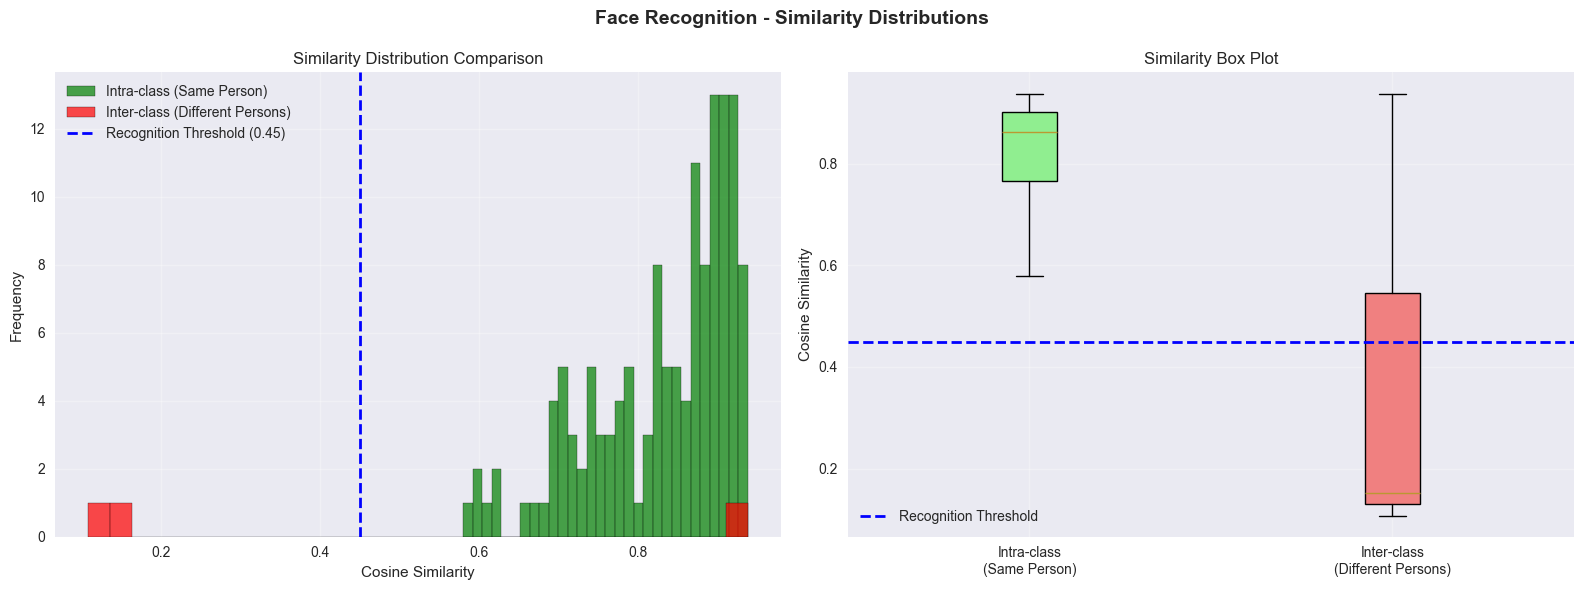

✅ Similarity distribution plots created!


In [6]:
# Visualize similarity distributions
if intra_class_similarities or inter_class_similarities:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Face Recognition - Similarity Distributions', fontsize=14, fontweight='bold')
    
    # Plot 1: Histogram comparison
    if intra_class_similarities:
        axes[0].hist(intra_class_similarities, bins=30, alpha=0.7, label='Intra-class (Same Person)', color='green', edgecolor='black')
    if inter_class_similarities:
        axes[0].hist(inter_class_similarities, bins=30, alpha=0.7, label='Inter-class (Different Persons)', color='red', edgecolor='black')
    
    axes[0].axvline(x=0.45, color='blue', linestyle='--', linewidth=2, label='Recognition Threshold (0.45)')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Similarity Distribution Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Box plot comparison
    data_to_plot = []
    labels = []
    if intra_class_similarities:
        data_to_plot.append(intra_class_similarities)
        labels.append('Intra-class\n(Same Person)')
    if inter_class_similarities:
        data_to_plot.append(inter_class_similarities)
        labels.append('Inter-class\n(Different Persons)')
    
    if data_to_plot:
        bp = axes[1].boxplot(data_to_plot, labels=labels, patch_artist=True)
        colors = ['lightgreen', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors[:len(data_to_plot)]):
            patch.set_facecolor(color)
        axes[1].axhline(y=0.45, color='blue', linestyle='--', linewidth=2, label='Recognition Threshold')
        axes[1].set_ylabel('Cosine Similarity')
        axes[1].set_title('Similarity Box Plot')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("✅ Similarity distribution plots created!")
else:
    print("⚠️ Not enough data for similarity visualization.")

## 4. Recognition Accuracy Metrics

Calculate comprehensive accuracy metrics for the face recognition system.

In [7]:
# Simulate recognition scenarios to calculate accuracy metrics
print("📊 Calculating Recognition Accuracy Metrics...")

# Recognition threshold
RECOGNITION_THRESHOLD = 0.45

# Calculate metrics based on similarity distributions
metrics = {}

if intra_class_similarities:
    # True Positive Rate (Same person recognized correctly)
    tp_rate = np.mean(np.array(intra_class_similarities) >= RECOGNITION_THRESHOLD) * 100
    metrics['true_positive_rate'] = tp_rate
    metrics['intra_class_mean'] = np.mean(intra_class_similarities)
    metrics['intra_class_std'] = np.std(intra_class_similarities)

if inter_class_similarities:
    # False Positive Rate (Different person wrongly recognized)
    fp_rate = np.mean(np.array(inter_class_similarities) >= RECOGNITION_THRESHOLD) * 100
    metrics['false_positive_rate'] = fp_rate
    metrics['true_negative_rate'] = 100 - fp_rate
    metrics['inter_class_mean'] = np.mean(inter_class_similarities)
    metrics['inter_class_std'] = np.std(inter_class_similarities)

# Calculate overall metrics
if 'true_positive_rate' in metrics and 'false_positive_rate' in metrics:
    metrics['accuracy'] = (metrics['true_positive_rate'] + metrics['true_negative_rate']) / 2
    
    # Precision and F1 (approximated)
    if metrics['true_positive_rate'] + metrics['false_positive_rate'] > 0:
        metrics['precision'] = (metrics['true_positive_rate'] / 
                               (metrics['true_positive_rate'] + metrics['false_positive_rate'])) * 100
    
    # F1 Score
    if 'precision' in metrics and metrics['true_positive_rate'] > 0:
        precision = metrics['precision'] / 100
        recall = metrics['true_positive_rate'] / 100
        if precision + recall > 0:
            metrics['f1_score'] = 2 * (precision * recall) / (precision + recall) * 100

# Store total counts
metrics['total_students'] = len(embeddings)
metrics['total_embeddings'] = sum(len(v) for v in multi_embeddings.values()) if multi_embeddings else len(embeddings)

print("✅ Metrics calculated!")

📊 Calculating Recognition Accuracy Metrics...
✅ Metrics calculated!


In [8]:
# Display accuracy metrics in formatted output
print("="*70)
print("FACIAL RECOGNITION ACCURACY METRICS")
print("="*70)

print("\n📊 RECOGNITION RATES:")
print("-"*70)
if 'true_positive_rate' in metrics:
    print(f"  True Positive Rate (Recall):     {metrics['true_positive_rate']:.2f}%")
if 'false_positive_rate' in metrics:
    print(f"  False Positive Rate:              {metrics['false_positive_rate']:.2f}%")
if 'true_negative_rate' in metrics:
    print(f"  True Negative Rate (Specificity): {metrics['true_negative_rate']:.2f}%")

print("\n🎯 OVERALL PERFORMANCE:")
print("-"*70)
if 'accuracy' in metrics:
    print(f"  Overall Accuracy:                 {metrics['accuracy']:.2f}%")
if 'precision' in metrics:
    print(f"  Precision:                        {metrics['precision']:.2f}%")
if 'f1_score' in metrics:
    print(f"  F1 Score:                         {metrics['f1_score']:.2f}%")

print("\n📈 SIMILARITY STATISTICS:")
print("-"*70)
if 'intra_class_mean' in metrics:
    print(f"  Intra-class Mean Similarity:      {metrics['intra_class_mean']:.4f}")
    print(f"  Intra-class Std Deviation:        {metrics['intra_class_std']:.4f}")
if 'inter_class_mean' in metrics:
    print(f"  Inter-class Mean Similarity:      {metrics['inter_class_mean']:.4f}")
    print(f"  Inter-class Std Deviation:        {metrics['inter_class_std']:.4f}")

print("\n📚 DATABASE STATISTICS:")
print("-"*70)
print(f"  Total Registered Students:        {metrics.get('total_students', 0)}")
print(f"  Total Face Embeddings:            {metrics.get('total_embeddings', 0)}")
print(f"  Recognition Threshold:            {RECOGNITION_THRESHOLD}")

# Performance interpretation
print("\n🏆 INTERPRETATION:")
print("-"*70)
if 'accuracy' in metrics:
    if metrics['accuracy'] >= 95:
        quality = "Excellent"
        emoji = "🌟"
    elif metrics['accuracy'] >= 90:
        quality = "Very Good"
        emoji = "✅"
    elif metrics['accuracy'] >= 80:
        quality = "Good"
        emoji = "👍"
    elif metrics['accuracy'] >= 70:
        quality = "Moderate"
        emoji = "⚠️"
    else:
        quality = "Needs Improvement"
        emoji = "❌"
    
    print(f"  {emoji} Model Quality: {quality}")
    print(f"  The model correctly identifies {metrics['accuracy']:.1f}% of faces.")
    
print("="*70)

FACIAL RECOGNITION ACCURACY METRICS

📊 RECOGNITION RATES:
----------------------------------------------------------------------
  True Positive Rate (Recall):     100.00%
  False Positive Rate:              33.33%
  True Negative Rate (Specificity): 66.67%

🎯 OVERALL PERFORMANCE:
----------------------------------------------------------------------
  Overall Accuracy:                 83.33%
  Precision:                        75.00%
  F1 Score:                         85.71%

📈 SIMILARITY STATISTICS:
----------------------------------------------------------------------
  Intra-class Mean Similarity:      0.8305
  Intra-class Std Deviation:        0.0889
  Inter-class Mean Similarity:      0.3995
  Inter-class Std Deviation:        0.3816

📚 DATABASE STATISTICS:
----------------------------------------------------------------------
  Total Registered Students:        3
  Total Face Embeddings:            30
  Recognition Threshold:            0.45

🏆 INTERPRETATION:
-----------------

## 5. Threshold Analysis

Analyze how different recognition thresholds affect accuracy.

In [9]:
# Analyze accuracy at different thresholds
print("📈 Analyzing Threshold Impact on Accuracy...")

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_analysis = []

for thresh in thresholds:
    tpr = np.mean(np.array(intra_class_similarities) >= thresh) * 100 if intra_class_similarities else 0
    fpr = np.mean(np.array(inter_class_similarities) >= thresh) * 100 if inter_class_similarities else 0
    tnr = 100 - fpr
    accuracy = (tpr + tnr) / 2 if tpr > 0 or tnr > 0 else 0
    
    threshold_analysis.append({
        'threshold': thresh,
        'tpr': tpr,
        'fpr': fpr,
        'tnr': tnr,
        'accuracy': accuracy
    })

thresh_df = pd.DataFrame(threshold_analysis)

# Find optimal threshold
if len(thresh_df) > 0 and thresh_df['accuracy'].max() > 0:
    optimal_idx = thresh_df['accuracy'].idxmax()
    optimal_thresh = thresh_df.loc[optimal_idx, 'threshold']
    optimal_acc = thresh_df.loc[optimal_idx, 'accuracy']
    
    print(f"\n🎯 Optimal Threshold: {optimal_thresh:.2f}")
    print(f"   Accuracy at optimal: {optimal_acc:.2f}%")
    print(f"   TPR at optimal: {thresh_df.loc[optimal_idx, 'tpr']:.2f}%")
    print(f"   FPR at optimal: {thresh_df.loc[optimal_idx, 'fpr']:.2f}%")

print("\n📊 Threshold Analysis Table:")
print(thresh_df[['threshold', 'tpr', 'fpr', 'accuracy']].to_string(index=False))

📈 Analyzing Threshold Impact on Accuracy...

🎯 Optimal Threshold: 0.20
   Accuracy at optimal: 83.33%
   TPR at optimal: 100.00%
   FPR at optimal: 33.33%

📊 Threshold Analysis Table:
 threshold        tpr        fpr  accuracy
      0.10 100.000000 100.000000 50.000000
      0.15 100.000000  66.666667 66.666667
      0.20 100.000000  33.333333 83.333333
      0.25 100.000000  33.333333 83.333333
      0.30 100.000000  33.333333 83.333333
      0.35 100.000000  33.333333 83.333333
      0.40 100.000000  33.333333 83.333333
      0.45 100.000000  33.333333 83.333333
      0.50 100.000000  33.333333 83.333333
      0.55 100.000000  33.333333 83.333333
      0.60  98.518519  33.333333 82.592593
      0.65  95.555556  33.333333 81.111111
      0.70  88.888889  33.333333 77.777778
      0.75  78.518519  33.333333 72.592593
      0.80  68.148148  33.333333 67.407407
      0.85  54.074074  33.333333 60.370370


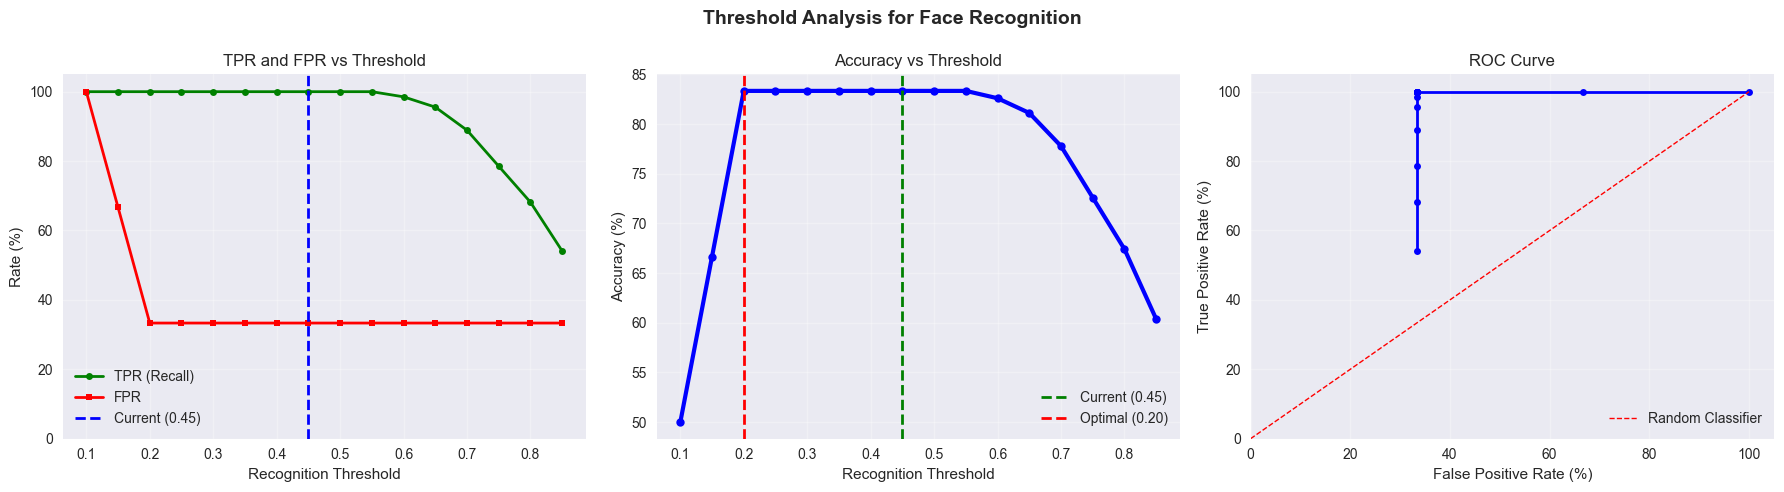

✅ Threshold analysis plots created!


In [10]:
# Visualize threshold analysis
if len(thresh_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Threshold Analysis for Face Recognition', fontsize=14, fontweight='bold')
    
    # Plot 1: TPR and FPR vs Threshold
    axes[0].plot(thresh_df['threshold'], thresh_df['tpr'], 'g-', linewidth=2, marker='o', label='TPR (Recall)', markersize=5)
    axes[0].plot(thresh_df['threshold'], thresh_df['fpr'], 'r-', linewidth=2, marker='s', label='FPR', markersize=5)
    axes[0].axvline(x=RECOGNITION_THRESHOLD, color='blue', linestyle='--', linewidth=2, label=f'Current ({RECOGNITION_THRESHOLD})')
    axes[0].set_xlabel('Recognition Threshold')
    axes[0].set_ylabel('Rate (%)')
    axes[0].set_title('TPR and FPR vs Threshold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 105])
    
    # Plot 2: Accuracy vs Threshold
    axes[1].plot(thresh_df['threshold'], thresh_df['accuracy'], 'b-', linewidth=3, marker='o', markersize=6)
    axes[1].axvline(x=RECOGNITION_THRESHOLD, color='green', linestyle='--', linewidth=2, label=f'Current ({RECOGNITION_THRESHOLD})')
    if 'optimal_thresh' in dir():
        axes[1].axvline(x=optimal_thresh, color='red', linestyle='--', linewidth=2, label=f'Optimal ({optimal_thresh:.2f})')
    axes[1].set_xlabel('Recognition Threshold')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy vs Threshold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: ROC Curve
    axes[2].plot(thresh_df['fpr'], thresh_df['tpr'], 'b-', linewidth=2, marker='o', markersize=5)
    axes[2].plot([0, 100], [0, 100], 'r--', linewidth=1, label='Random Classifier')
    axes[2].set_xlabel('False Positive Rate (%)')
    axes[2].set_ylabel('True Positive Rate (%)')
    axes[2].set_title('ROC Curve')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlim([0, 105])
    axes[2].set_ylim([0, 105])
    
    plt.tight_layout()
    plt.show()
    print("✅ Threshold analysis plots created!")
else:
    print("⚠️ Not enough data for threshold visualization.")

## 6. Per-Student Analysis

Analyze recognition quality for individual students.

In [11]:
# Per-student embedding quality analysis
print("👤 Per-Student Embedding Quality Analysis...")

student_quality = []

if multi_embeddings:
    for student_id, embs in multi_embeddings.items():
        if len(embs) < 2:
            quality_score = 0.5  # Default for single embedding
        else:
            # Calculate intra-student similarity
            similarities = []
            for i in range(len(embs)):
                for j in range(i + 1, len(embs)):
                    sim = cosine_similarity(embs[i], embs[j])
                    similarities.append(sim)
            
            mean_sim = np.mean(similarities)
            std_sim = np.std(similarities)
            quality_score = mean_sim * (1 - std_sim)  # High mean, low std = good
        
        # Calculate separation from other students
        separations = []
        for other_id, other_emb in embeddings.items():
            if other_id != student_id:
                sep = 1 - cosine_similarity(embeddings[student_id], other_emb)
                separations.append(sep)
        
        avg_separation = np.mean(separations) if separations else 0
        
        student_name = student_info.get(student_id, {}).get('name', student_id)
        
        student_quality.append({
            'student_id': student_id,
            'name': student_name,
            'num_embeddings': len(embs),
            'quality_score': quality_score,
            'avg_separation': avg_separation
        })

if student_quality:
    quality_df = pd.DataFrame(student_quality)
    quality_df = quality_df.sort_values('quality_score', ascending=False)
    
    print("\n📊 Student Embedding Quality:")
    print(quality_df.to_string(index=False))
    
    # Identify students that may need retraining
    low_quality = quality_df[quality_df['quality_score'] < 0.5]
    if len(low_quality) > 0:
        print("\n⚠️ Students with Low Quality Embeddings (may need retraining):")
        print(low_quality[['name', 'quality_score']].to_string(index=False))
else:
    print("No multi-embedding data available for per-student analysis.")

👤 Per-Student Embedding Quality Analysis...

📊 Student Embedding Quality:
       student_id                name  num_embeddings  quality_score  avg_separation
DASH_stu-00000079  Kavinda Abeysekara              10       0.889103        0.477138
DASH_stu-00000080     Sanduni Rodrigo              10       0.825579        0.454411
DASH_stu-00000078 tharusha Senanayake              10       0.679275        0.870039


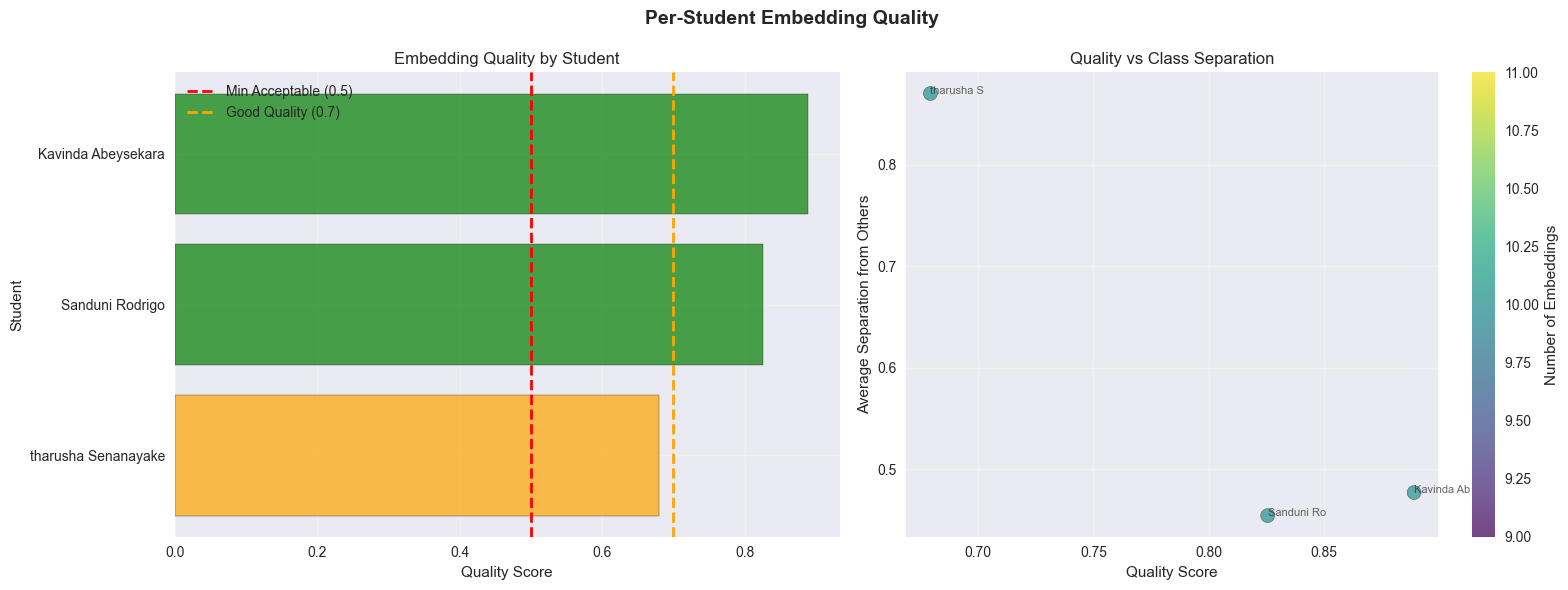

✅ Per-student quality visualization created!


In [12]:
# Visualize per-student quality
if student_quality:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Per-Student Embedding Quality', fontsize=14, fontweight='bold')
    
    # Sort by quality score
    quality_df_sorted = quality_df.sort_values('quality_score', ascending=True)
    
    # Plot 1: Quality Score Bar Chart
    colors = ['red' if q < 0.5 else 'orange' if q < 0.7 else 'green' for q in quality_df_sorted['quality_score']]
    axes[0].barh(quality_df_sorted['name'], quality_df_sorted['quality_score'], color=colors, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Min Acceptable (0.5)')
    axes[0].axvline(x=0.7, color='orange', linestyle='--', linewidth=2, label='Good Quality (0.7)')
    axes[0].set_xlabel('Quality Score')
    axes[0].set_ylabel('Student')
    axes[0].set_title('Embedding Quality by Student')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Quality vs Separation Scatter
    scatter = axes[1].scatter(
        quality_df['quality_score'],
        quality_df['avg_separation'],
        c=quality_df['num_embeddings'],
        cmap='viridis',
        s=100,
        edgecolors='black',
        alpha=0.7
    )
    plt.colorbar(scatter, ax=axes[1], label='Number of Embeddings')
    axes[1].set_xlabel('Quality Score')
    axes[1].set_ylabel('Average Separation from Others')
    axes[1].set_title('Quality vs Class Separation')
    axes[1].grid(True, alpha=0.3)
    
    # Add annotations
    for _, row in quality_df.iterrows():
        axes[1].annotate(row['name'][:10], (row['quality_score'], row['avg_separation']),
                        fontsize=8, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    print("✅ Per-student quality visualization created!")
else:
    print("⚠️ Not enough data for per-student visualization.")

## 7. Confusion Matrix Simulation

Simulate recognition scenarios and create confusion matrix.

In [13]:
# Create simulated recognition results for confusion matrix
print("📊 Generating Confusion Matrix Simulation...")

if len(embeddings) >= 2:
    # Simulate recognition by matching each embedding against all others
    true_labels = []
    predicted_labels = []
    confidences = []
    
    student_ids = list(embeddings.keys())
    
    for query_id in student_ids:
        query_emb = embeddings[query_id]
        
        # Find best match
        best_match = None
        best_sim = -1
        
        for target_id in student_ids:
            sim = cosine_similarity(query_emb, embeddings[target_id])
            if sim > best_sim:
                best_sim = sim
                best_match = target_id
        
        # Determine prediction
        if best_sim >= RECOGNITION_THRESHOLD:
            predicted_labels.append(best_match)
        else:
            predicted_labels.append('Unknown')
        
        true_labels.append(query_id)
        confidences.append(best_sim)
    
    # Create confusion data
    from sklearn.metrics import confusion_matrix, classification_report
    
    # Calculate metrics
    correct = sum(1 for t, p in zip(true_labels, predicted_labels) if t == p)
    total = len(true_labels)
    accuracy = correct / total * 100 if total > 0 else 0
    
    print(f"\n🎯 Recognition Simulation Results:")
    print(f"   Total queries: {total}")
    print(f"   Correct matches: {correct}")
    print(f"   Recognition Rate: {accuracy:.2f}%")
    print(f"   Average Confidence: {np.mean(confidences):.4f}")
else:
    print("⚠️ Need at least 2 students for confusion matrix analysis.")

📊 Generating Confusion Matrix Simulation...

🎯 Recognition Simulation Results:
   Total queries: 3
   Correct matches: 3
   Recognition Rate: 100.00%
   Average Confidence: 1.0000


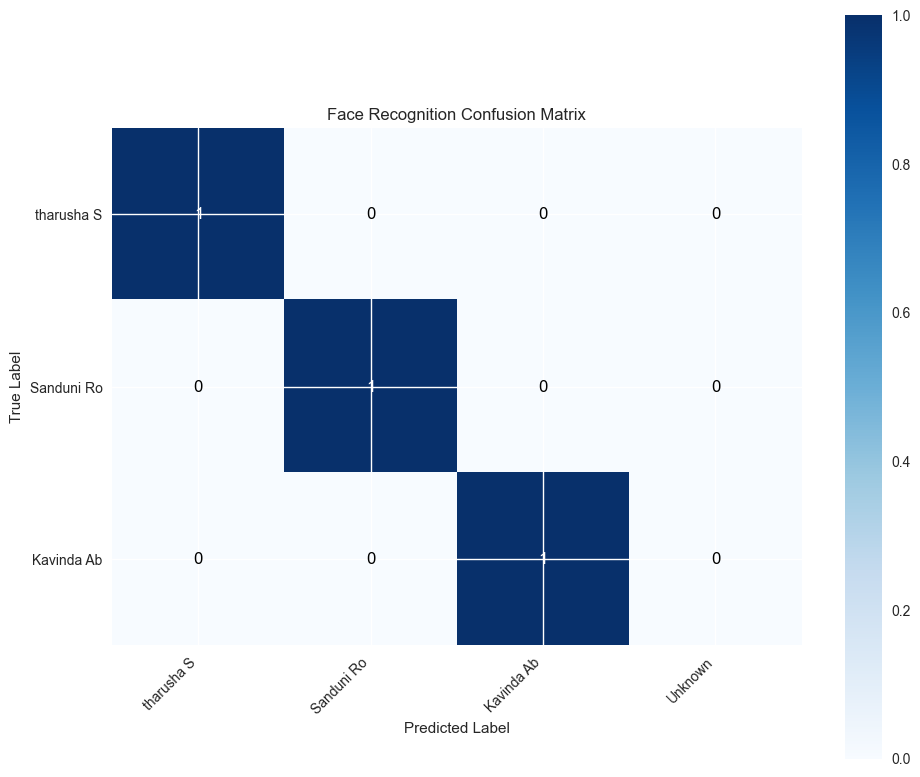

✅ Confusion matrix visualization created!


In [14]:
# Visualize confusion matrix
if len(embeddings) >= 2 and 'true_labels' in dir():
    # Create student ID to name mapping
    id_to_name = {sid: student_info.get(sid, {}).get('name', sid)[:10] for sid in student_ids}
    
    # Create confusion matrix
    all_labels = student_ids + ['Unknown']
    cm = np.zeros((len(student_ids), len(all_labels)), dtype=int)
    
    for i, true_id in enumerate(student_ids):
        for j, pred_label in enumerate(all_labels):
            cm[i, j] = sum(1 for t, p in zip(true_labels, predicted_labels) 
                          if t == true_id and p == pred_label)
    
    fig, ax = plt.subplots(figsize=(max(10, len(student_ids)), max(8, len(student_ids) * 0.8)))
    
    # Create heatmap
    im = ax.imshow(cm, cmap='Blues')
    
    # Set labels
    ax.set_xticks(np.arange(len(all_labels)))
    ax.set_yticks(np.arange(len(student_ids)))
    ax.set_xticklabels([id_to_name.get(l, l) for l in all_labels], rotation=45, ha='right')
    ax.set_yticklabels([id_to_name.get(s, s) for s in student_ids])
    
    # Add text annotations
    for i in range(len(student_ids)):
        for j in range(len(all_labels)):
            text = ax.text(j, i, cm[i, j], ha='center', va='center', 
                          color='white' if cm[i, j] > cm.max()/2 else 'black')
    
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Face Recognition Confusion Matrix')
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    
    print("✅ Confusion matrix visualization created!")
else:
    print("⚠️ Not enough data for confusion matrix visualization.")

## 8. Summary and Recommendations

Generate comprehensive analysis summary and improvement recommendations.

In [15]:
# Generate comprehensive summary
print("="*70)
print("FACIAL RECOGNITION MODEL - ACCURACY ANALYSIS SUMMARY")
print("="*70)

# Determine overall quality
if 'accuracy' in metrics:
    if metrics['accuracy'] >= 95:
        overall_quality = "EXCELLENT"
        emoji = "🌟"
    elif metrics['accuracy'] >= 90:
        overall_quality = "VERY GOOD"
        emoji = "✅"
    elif metrics['accuracy'] >= 80:
        overall_quality = "GOOD"
        emoji = "👍"
    elif metrics['accuracy'] >= 70:
        overall_quality = "MODERATE"
        emoji = "⚠️"
    else:
        overall_quality = "NEEDS IMPROVEMENT"
        emoji = "❌"
else:
    overall_quality = "INSUFFICIENT DATA"
    emoji = "❓"

print(f"\n{emoji} OVERALL MODEL QUALITY: {overall_quality}")
print("-"*70)

# Key metrics summary
print("\n📊 KEY METRICS:")
print("-"*70)
print(f"  Total Registered Students:     {metrics.get('total_students', 0)}")
print(f"  Total Face Embeddings:         {metrics.get('total_embeddings', 0)}")
if 'accuracy' in metrics:
    print(f"  Recognition Accuracy:          {metrics['accuracy']:.2f}%")
if 'true_positive_rate' in metrics:
    print(f"  True Positive Rate:            {metrics['true_positive_rate']:.2f}%")
if 'false_positive_rate' in metrics:
    print(f"  False Positive Rate:           {metrics['false_positive_rate']:.2f}%")

# Strengths
print("\n✅ STRENGTHS:")
print("-"*70)
strengths = []
if 'true_positive_rate' in metrics and metrics['true_positive_rate'] >= 90:
    strengths.append(f"High recognition rate ({metrics['true_positive_rate']:.1f}%)")
if 'false_positive_rate' in metrics and metrics['false_positive_rate'] <= 5:
    strengths.append(f"Low false positive rate ({metrics['false_positive_rate']:.1f}%)")
if 'intra_class_mean' in metrics and metrics['intra_class_mean'] >= 0.8:
    strengths.append(f"High intra-class consistency ({metrics['intra_class_mean']:.3f})")
if metrics.get('total_embeddings', 0) >= metrics.get('total_students', 0) * 3:
    strengths.append("Good multi-embedding coverage")

if strengths:
    for s in strengths:
        print(f"  • {s}")
else:
    print("  • System is functional with basic performance")

# Weaknesses
print("\n⚠️ AREAS FOR IMPROVEMENT:")
print("-"*70)
weaknesses = []
if 'true_positive_rate' in metrics and metrics['true_positive_rate'] < 90:
    weaknesses.append(f"Recognition rate could be higher ({metrics['true_positive_rate']:.1f}%)")
if 'false_positive_rate' in metrics and metrics['false_positive_rate'] > 10:
    weaknesses.append(f"High false positive rate ({metrics['false_positive_rate']:.1f}%)")
if metrics.get('total_students', 0) < 5:
    weaknesses.append("Small sample size for comprehensive analysis")
if student_quality:
    low_q = [s for s in student_quality if s['quality_score'] < 0.5]
    if low_q:
        weaknesses.append(f"{len(low_q)} students have low quality embeddings")

if weaknesses:
    for w in weaknesses:
        print(f"  • {w}")
else:
    print("  • No critical weaknesses identified")

FACIAL RECOGNITION MODEL - ACCURACY ANALYSIS SUMMARY

👍 OVERALL MODEL QUALITY: GOOD
----------------------------------------------------------------------

📊 KEY METRICS:
----------------------------------------------------------------------
  Total Registered Students:     3
  Total Face Embeddings:         30
  Recognition Accuracy:          83.33%
  True Positive Rate:            100.00%
  False Positive Rate:           33.33%

✅ STRENGTHS:
----------------------------------------------------------------------
  • High recognition rate (100.0%)
  • High intra-class consistency (0.831)
  • Good multi-embedding coverage

⚠️ AREAS FOR IMPROVEMENT:
----------------------------------------------------------------------
  • High false positive rate (33.3%)
  • Small sample size for comprehensive analysis


In [16]:
# Recommendations
print("\n🔧 RECOMMENDATIONS FOR IMPROVEMENT:")
print("-"*70)

recommendations = [
    "1. 📸 Capture More Face Images:",
    "   • Capture 10+ images per student from different angles",
    "   • Include various lighting conditions",
    "   • Capture with and without glasses/accessories",
    "",
    "2. 🎯 Optimize Recognition Threshold:",
    f"   • Current threshold: {RECOGNITION_THRESHOLD}",
]

if 'optimal_thresh' in dir():
    recommendations.append(f"   • Recommended threshold: {optimal_thresh:.2f}")

recommendations.extend([
    "   • Adjust based on your security requirements",
    "",
    "3. 🔄 Regular Retraining:",
    "   • Retrain embeddings periodically",
    "   • Update when students' appearances change",
    "   • Remove old/outdated embeddings",
    "",
    "4. 🖥️ Hardware Optimization:",
    "   • Use GPU for faster processing (CUDA)",
    "   • Ensure adequate lighting in capture area",
    "   • Use HD cameras (720p minimum)",
    "",
    "5. 🔒 Enable Anti-Spoofing:",
    "   • Enable liveness detection for security",
    "   • Prevents photo/video spoofing attacks",
    "",
    "6. 📊 Monitor Performance:",
    "   • Track recognition accuracy over time",
    "   • Log failed recognition attempts",
    "   • Analyze patterns in misidentifications"
])

for rec in recommendations:
    print(rec)

print("\n" + "="*70)
print("📋 ANALYSIS COMPLETE")
print("="*70)


🔧 RECOMMENDATIONS FOR IMPROVEMENT:
----------------------------------------------------------------------
1. 📸 Capture More Face Images:
   • Capture 10+ images per student from different angles
   • Include various lighting conditions
   • Capture with and without glasses/accessories

2. 🎯 Optimize Recognition Threshold:
   • Current threshold: 0.45
   • Recommended threshold: 0.20
   • Adjust based on your security requirements

3. 🔄 Regular Retraining:
   • Retrain embeddings periodically
   • Update when students' appearances change
   • Remove old/outdated embeddings

4. 🖥️ Hardware Optimization:
   • Use GPU for faster processing (CUDA)
   • Ensure adequate lighting in capture area
   • Use HD cameras (720p minimum)

5. 🔒 Enable Anti-Spoofing:
   • Enable liveness detection for security
   • Prevents photo/video spoofing attacks

6. 📊 Monitor Performance:
   • Track recognition accuracy over time
   • Log failed recognition attempts
   • Analyze patterns in misidentifications

📋

In [17]:
# Save results to JSON file
import json

results_summary = {
    'evaluation_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'system': 'Facial Recognition Attendance System',
    'model_type': 'FaceNet/ArcFace',
    'recognition_threshold': RECOGNITION_THRESHOLD,
    'database_statistics': {
        'total_students': metrics.get('total_students', 0),
        'total_embeddings': metrics.get('total_embeddings', 0)
    },
    'accuracy_metrics': {
        'accuracy': metrics.get('accuracy', None),
        'true_positive_rate': metrics.get('true_positive_rate', None),
        'false_positive_rate': metrics.get('false_positive_rate', None),
        'precision': metrics.get('precision', None),
        'f1_score': metrics.get('f1_score', None)
    },
    'similarity_statistics': {
        'intra_class_mean': metrics.get('intra_class_mean', None),
        'intra_class_std': metrics.get('intra_class_std', None),
        'inter_class_mean': metrics.get('inter_class_mean', None),
        'inter_class_std': metrics.get('inter_class_std', None)
    },
    'overall_quality': overall_quality,
    'recommendations': [
        'Capture more face images per student (10+ recommended)',
        'Optimize recognition threshold based on security needs',
        'Retrain embeddings periodically',
        'Enable anti-spoofing for security',
        'Monitor performance over time'
    ]
}

# Convert numpy values to Python native types
def convert_numpy(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    return obj

results_summary = convert_numpy(results_summary)

# Save to JSON
output_path = 'model_accuracy_results.json'
with open(output_path, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"✅ Results saved to: {output_path}")

# Display final summary
print("\n📋 FINAL SUMMARY:")
print(f"  Model Quality: {overall_quality}")
if 'accuracy' in metrics:
    print(f"  Recognition Accuracy: {metrics['accuracy']:.2f}%")
print(f"  Total Students: {metrics.get('total_students', 0)}")
print(f"  Total Embeddings: {metrics.get('total_embeddings', 0)}")
print(f"  Analysis Date: {results_summary['evaluation_date']}")

✅ Results saved to: model_accuracy_results.json

📋 FINAL SUMMARY:
  Model Quality: GOOD
  Recognition Accuracy: 83.33%
  Total Students: 3
  Total Embeddings: 30
  Analysis Date: 2026-01-11 21:44:00
